<!--Información del curso-->
<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/banner_dl.png">

<center><h1 style="font-size:2em;color:#2467C0"> Caso de estudio: Juegos Olimpicos  </h1></center>

<center><h2 style="font-size:2em;color:#840700">  Pandas   </h4></center>

<br>
<table>
<col width="550">
<col width="450">
<tr>
<td><img src="figuras/juegos_olimpicos.jpg" align="left" style="width:500px"/></td>
<td>

Los Juegos Olímpicos, también conocidos como Olimpiadas, son un importante evento deportivo internacional que se celebra cada cuatro años, reuniendo a atletas de todo el mundo para competir en diversas disciplinas deportivas.
   
    
<br>
</td>
</tr>
</table>

# Librerías

Cargando las bibliotecas que necesitamos 


In [253]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Datos
* Revisar las primeras líneas de los archivos
* Utilizar las funciones de descripción e información para recopilar información estadística, tipos de datos, nombres de columnas y otra información. 



In [254]:
#Cargar el archivo datos/athlete_events.csv en un dataframe llamado df_atletas
df_atletas = pd.read_csv("datos/athlete_events.csv")
df_atletas.shape

(271116, 15)

In [255]:
#Revisar las primeras líneas de los archivos
df_atletas.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [256]:
# Encontrar los principales valores estadísticos 
df_atletas.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [257]:
#Cargar el archivo datos/datasets_31029_40943_noc_regions.csv en un dataframe llamado df_paises
df_paises = pd.read_csv("datos/datasets_31029_40943_noc_regions.csv")

In [258]:
#Mostrar las primeras líneas
df_paises.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


### 1 . Combinando los dataframes
Combinar los dataframes **df_atletas** y **df_paises** en un dataframe llamado **df**. 

*Utilizar la columna 'NOC'*

In [259]:
#Utilizar pd.merge
df = pd.merge(df_atletas, df_paises, how = 'left', on = 'NOC') #Mantiene la tabla izquierda (La original) y solo añade coincidencias de la derecha.

In [260]:
#Mostrar las primeras líneas
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


### 2. Dataframe de medallas de oro 
Crear un dataframe solo de medallas de oro


In [261]:
#Mostrar los posibles valores  de la columna Medal
df['Medal'].unique().tolist()

[nan, 'Gold', 'Bronze', 'Silver']

In [262]:
#Crear el dataframe df_MedallasOro solo con ganadores de medallas de oro.
df_MedallasOro = df[df['Medal'] == 'Gold']
df_MedallasOro.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
42,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold,Finland,NaN
44,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Horse Vault,Gold,Finland,NaN
48,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Pommelled Horse,Gold,Finland,NaN
60,20,Kjetil Andr Aamodt,M,20.0,176.0,85.0,Norway,NOR,1992 Winter,1992,Winter,Albertville,Alpine Skiing,Alpine Skiing Men's Super G,Gold,Norway,NaN


#####  Distribución de edades de medallas de oro 


In [263]:
# Revisar si la columna Age tiene elementos nulos 
df_MedallasOro['Age'].isnull().sum()

np.int64(148)

In [264]:
#Revisar los diferentes valores de Age
df_MedallasOro.sort_values('Age')['Age'].unique()

array([13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60., 63., 64., nan])

In [265]:
# Eliminar las filas con 'nan' 
df_MedallasOro = df_MedallasOro.dropna(subset = ['Age']) #Solo de la columna Age
df_MedallasOro['Age'].isnull().sum()

np.int64(0)

In [266]:
#Mostrar nuevamente los posibles valores de la columna 'Age'
df_MedallasOro.sort_values('Age')['Age'].unique()

array([13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60., 63., 64.])

<Axes: >

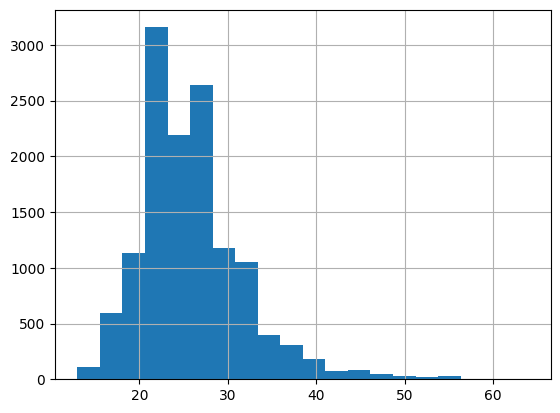

In [267]:
#Mostrar un histograma de la columna 'Age' con 20 bins
df_MedallasOro['Age'].hist(bins = 20) 

In [268]:
# ¿Cuantas personas mayores a 50 han ganado una medalla de oro?
(df_MedallasOro['Age']>50).sum()

np.int64(65)

##### ¿Qué disciplinas te permiten conseguir una medalla de oro después de los cincuenta? 

In [269]:
#Mostrar las diferentes disciplinas (mayores a 50)
df_MedallasOro[df_MedallasOro['Age']>50]['Sport'].unique().tolist()

['Equestrianism',
 'Sailing',
 'Alpinism',
 'Art Competitions',
 'Curling',
 'Roque',
 'Shooting',
 'Archery',
 'Croquet']

In [270]:
#Mostrar el número de ganadores por disciplina (mayores a 50)
df_MedallasOro[df_MedallasOro['Age'] > 50]['Sport'].value_counts()

Sport
Equestrianism       18
Sailing             12
Shooting            11
Archery             11
Art Competitions     8
Curling              2
Alpinism             1
Roque                1
Croquet              1
Name: count, dtype: int64

### 3. Mujeres en atletismo 


In [271]:
# Crear un dataframe para mujeres llamado df_women 
# Considerar solamente los juegos de verano

In [272]:
df_women = df[(df['Sex']=='F') & (df['Season'] == 'Summer')]

In [273]:
df_women.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN
27,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 4 x 100 metres Relay,NaN,Netherlands,NaN
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN,Finland,NaN
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN,Finland,NaN
79,21,Ragnhild Margrethe Aamodt,F,27.0,163.0,NaN,Norway,NOR,2008 Summer,2008,Summer,Beijing,Handball,Handball Women's Handball,Gold,Norway,NaN


<Axes: xlabel='Year', ylabel='count'>

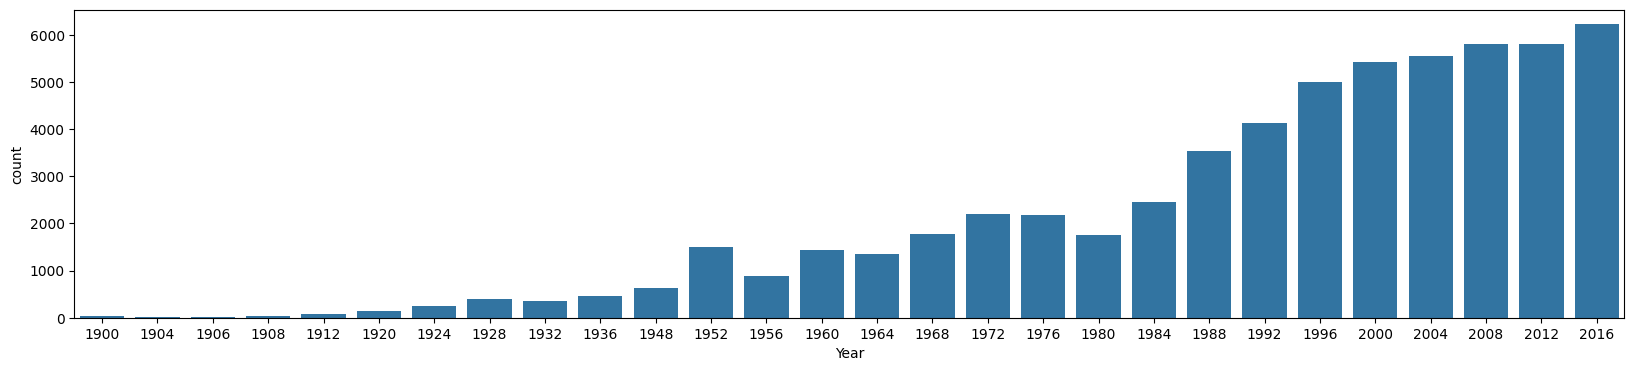

In [274]:
#Crear un gráfico en el que colocamos el año (en el eje x) 
# y contamos el número de participantes por edición de los juegos 
plt.figure(figsize= (20, 4))
sns.countplot(data = df_women, x = 'Year')

In [275]:
#Quitar elementos nulos de la columna Age
df_women = df_women.dropna(subset = ['Age'])
df_women['Age'].isnull().sum()

np.int64(0)

In [276]:
#Convertir a entero Age
df_women['Age'] = df_women['Age'].astype(int)

<Axes: xlabel='Age', ylabel='count'>

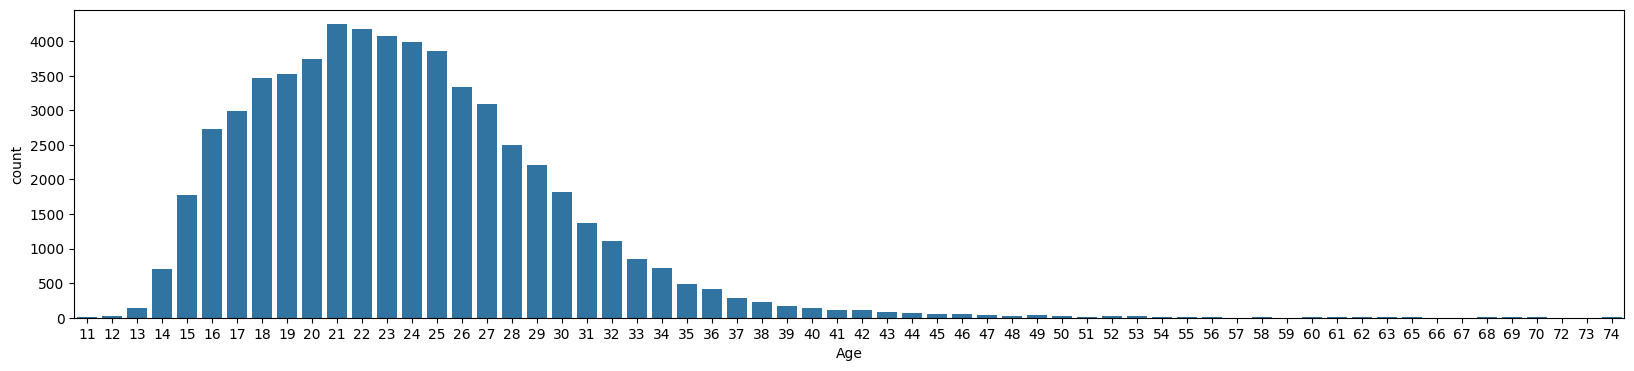

In [277]:
#Graficar
plt.figure(figsize= (20, 4))
sns.countplot(data = df_women, x = 'Age')

In [278]:
# Revisar el número de participantes mujeres en 2016

In [279]:
#Revisar el numero de participantes mujeres en 2016 con medalla de oro


### 4. Medallas de oro por país 


In [280]:
# Encontrar los cinco países con mayor número de medallas de oro 


# Ejercicio

**Parte 1**

Crear un dataframe para México llamado df_Mexico (solo datos de México)

In [281]:
df_Mexico = df[df['NOC'] == 'MEX']
df_Mexico.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
184,82,Enrique Abaroa Martnez,M,26.0,183.0,75.0,Mexico,MEX,2000 Summer,2000,Summer,Sydney,Tennis,Tennis Men's Doubles,NaN,Mexico,NaN
205,98,Hctor Abaunza,M,30.0,169.0,75.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Fencing,"Fencing Men's Foil, Individual",NaN,Mexico,NaN
206,98,Hctor Abaunza,M,30.0,169.0,75.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Fencing,"Fencing Men's Foil, Team",NaN,Mexico,NaN
207,98,Hctor Abaunza,M,30.0,169.0,75.0,Mexico,MEX,1968 Summer,1968,Summer,Mexico City,Fencing,"Fencing Men's Sabre, Team",NaN,Mexico,NaN
712,405,Jos Javier Abella Fanjul,M,22.0,176.0,66.0,Mexico,MEX,2016 Summer,2016,Summer,Rio de Janeiro,Football,Football Men's Football,NaN,Mexico,NaN


<div class="alert alert-success">
   
1. Mostrar la distribución de edades (frecuencias). 
</div>

In [282]:
df_Mexico = df_Mexico.dropna(subset=['Age'])
df_Mexico  = df_Mexico.astype({'Age':'int'}) #Otra manera de Convertir a enteros

<Axes: xlabel='Age', ylabel='count'>

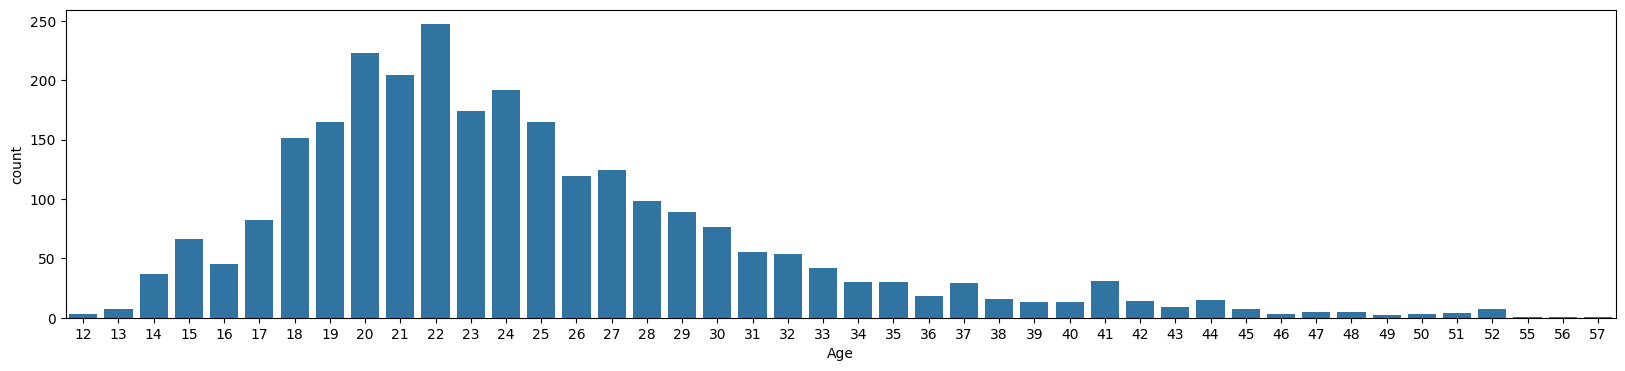

In [283]:
plt.figure(figsize=(20,4))
sns.countplot(data=df_Mexico, x='Age')

<div class="alert alert-success">
   
2. Mostrar la participación de desportistas mexicanos en las competencias de Verano (frecuencias por año). 
</div>

<Axes: xlabel='Year', ylabel='count'>

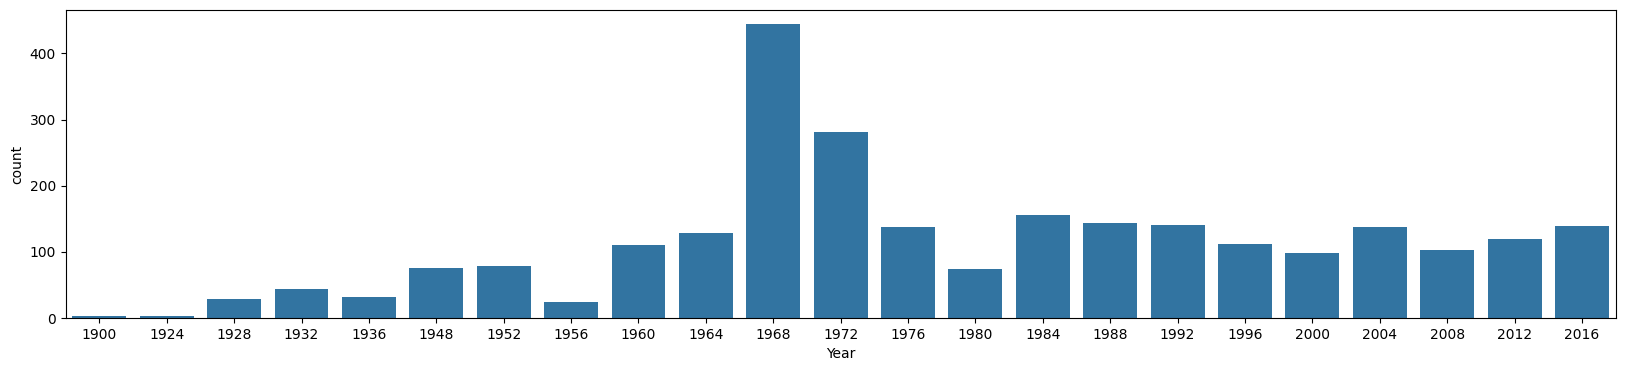

In [284]:
df_verano = df_Mexico[df_Mexico["Season"] == "Summer"]
plt.figure(figsize=(20,4))
sns.countplot(data=df_verano, x='Year')

<div class="alert alert-success">
   
3. Encontrar el numero total de medallas de oro, plata y bronce. 
</div>

In [285]:
df_Mexico['Medal'].value_counts()

Medal
Bronze    54
Gold      30
Silver    26
Name: count, dtype: int64

<div class="alert alert-success">

4. Encontrar a los deportistas mexicanos con 2 o más medallas. 
</div>


In [286]:
df_d = df_Mexico.groupby('Name')['Medal'].count().reset_index()
df_d = df_d[df_d['Medal'] >= 2]
df_d = df_d.sort_values(by='Medal', ascending=False)
df_d

,Name,Medal
688,Joaqun Capilla Prez,4
588,Humberto Mariles Corts,3
1017,Mara del Rosario Espinoza Espinoza,3
499,Germn Sal Snchez Snchez,2
693,Joaqun Prez de las Heras,2
1158,Paola Milagros Espinosa Snchez,2
1214,Ral Gonzlez Rodrguez,2
1309,Rubn Uriza Castro,2


# Ejercicio

**Parte 2**

*Utilizar todos los datos* 

<div class="alert alert-success">

5. Encontrar a los 5 deportistas con más medallas de oro en los juegos de Verano. 
</div>

In [296]:
df_5d = df[df['Season'] == 'Summer']
df_5d = df_5d.groupby('Name')['Medal'].count().reset_index()
df_5d = df_5d[df_5d['Medal'] >= 2]
df_5d = df_5d.sort_values(by='Medal', ascending=False)
df_5d.head()

,Name,Medal
74999,"Michael Fred Phelps, II",28
63261,Larysa Semenivna Latynina (Diriy-),18
81085,Nikolay Yefimovich Andrianov,15
13954,Borys Anfiyanovych Shakhlin,13
25492,Edoardo Mangiarotti,13


<div class="alert alert-success">
6. Encontrar el deportista (o deportistas) más joven en ganar un medalla de oro, también mencionar: la edad, año de obtención, disciplina y juegos (verano o invierno,). 
</div>

In [298]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [312]:
df_j = df.loc[0:, ['Name', 'Medal', 'Age', 'Year', 'Sport', 'Event', 'Season']]
df_j.dropna(subset=['Age', 'Medal'], inplace=True)
df_j.sort_values(by = 'Age', ascending = True, inplace = True)
df_j.head(1)

,Name,Medal,Age,Year,Sport,Event,Season
142882,Dimitrios Loundras,Bronze,10.0,1896,Gymnastics,"Gymnastics Men's Parallel Bars, Teams",Summer


<div class="alert alert-success">

7. ¿Qué deporte (sport) ha tenido el mayor número de participantes  en toda su historia (contando solo lo reportado en el archivo)? 

</div>

In [321]:
df_dp = df.groupby('Sport')['Sport'].count().sort_values(ascending=False)
df_df = pd.DataFrame(df_dp)
df_df.head(1)

,Sport
Sport,
Athletics,38624
